In [1]:
# If needed, install extra libs (run once in the environment)
# !pip install -U transformers datasets textstat wordfreq accelerate sentencepiece

from datasets import load_dataset, load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
import numpy as np
import textstat
from wordfreq import zipf_frequency
import re
from collections import Counter
from typing import Dict, List
import evaluate
import torch


C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
from datasets import DatasetDict,Dataset

cochrane_ds = load_dataset("GEM/cochrane-simplification", trust_remote_code=True)

# # Apply shuffle + select to each split
# cochrane_small = {
#     split: ds.shuffle(seed=42).select(range(100))
#     for split, ds in cochrane_ds.items()
# }
#
# # Convert back to DatasetDict (optional but cleaner)
# from datasets import DatasetDict
# cochrane_ds = DatasetDict(cochrane_small)



print(cochrane_ds["train"][0])
print(len(cochrane_ds["train"]))


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GEM/cochrane-simplification' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Using the latest cached version of the dataset since GEM/cochrane-simplification couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'cochrane-simplification' at C:\Users\Flaviu\.cache\huggingface\datasets\GEM___cochrane-simplification\cochrane-simplification\1.0.0\fd871e1bc42b6d9310e70d5667d5e874ed27d4ea7a6367f8042f1a2573deb2dd (last modified on Thu Dec 11 16:42:02 2025).


{'gem_id': 'cochrane-simplification-train-0', 'gem_parent_id': 'cochrane-simplification-train-0', 'source': 'Two trials met the inclusion criteria. One compared 2% ketanserin ointment in polyethylene glycol (PEG) with PEG alone, used twice a day by 40 participants with arterial leg ulcers, for eight weeks or until healing, whichever was sooner. One compared topical application of blood-derived concentrated growth factor (CGF) with standard dressing (polyurethane film or foam); both applied weekly for six weeks by 61 participants with non-healing ulcers (venous, diabetic arterial, neuropathic, traumatic, or vasculitic). Both trials were small, reported results inadequately, and were of low methodological quality. Short follow-up times (six and eight weeks) meant it would be difficult to capture sufficient healing events to allow us to make comparisons between treatments. One trial demonstrated accelerated wound healing in the ketanserin group compared with the control group. In the tria

In [3]:
model_name = "t5-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

cuda


In [2]:
def readability_metrics(text: str) -> Dict[str, float]:
    """Compute basic readability metrics for a text."""
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "smog_index": textstat.smog_index(text),
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
    }


def tokenize_words(text: str) -> List[str]:
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())


def is_common_word(word: str, threshold: float = 4.5) -> bool:
    """
    Uses Zipf frequency (0–7, higher = more common).
    ~4–5: common everyday English; <4: rare/technical.
    """
    return zipf_frequency(word, "en") >= threshold


def jargon_ratio(text: str, threshold: float = 4.5, min_len: int = 4) -> float:
    """
    Approximate jargon density using wordfreq.
    Returns % of tokens considered jargon.
    """
    words = tokenize_words(text)
    if not words:
        return 0.0
    jargon_words = [
        w for w in words
        if len(w) >= min_len and not is_common_word(w, threshold)
    ]
    return 100.0 * len(jargon_words) / len(words)


In [5]:
max_input_length = 256
max_target_length = 128

def preprocess_function(batch):
    inputs = []
    for src in batch["source"]:
        # Instruction-style prefix; you can tune wording
        inputs.append(f"simplify for better reading and understanding: {src}")

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
        padding="max_length",
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            batch["target"],
            max_length=max_target_length,
            truncation=True,
            padding="max_length",
        )["input_ids"]

    model_inputs["labels"] = labels
    return model_inputs

tokenized_simpl_ds = cochrane_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=cochrane_ds["train"].column_names,
)
tokenized_simpl_ds


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3568
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 411
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 480
    })
})

In [6]:
# ROUGE for overlap with reference simplifications
rouge = evaluate.load("rouge")


def postprocess_text(preds, labels):
    preds = [p.strip() for p in preds]
    labels = [l.strip() for l in labels]
    return preds, labels


def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Replace -100 (ignore index) with tokenizer.pad_token_id
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # For labels we need to remove ignored index (-100)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    # ROUGE
    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )

    # Readability & jargon – average over batch
    fk_grades = []
    fre_scores = []
    jargon_ratios = []

    for text in decoded_preds:
        rm = readability_metrics(text)
        fk_grades.append(rm["fk_grade"])
        fre_scores.append(rm["flesch_reading_ease"])
        jargon_ratios.append(jargon_ratio(text))

    metrics = {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "fk_grade_pred": float(np.nanmean(fk_grades)),
        "fre_pred": float(np.nanmean(fre_scores)),
        "jargon_pct_pred": float(np.nanmean(jargon_ratios)),
    }

    # Higher Flesch reading ease is better, lower FK grade & jargon_pct ideally
    return metrics


In [8]:
output_dir = "./t5-simplification-cochrane"

batch_size = 32  # adjust to your GPU
num_train_epochs = 2

args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=num_train_epochs,
    predict_with_generate=True,
    logging_strategy="steps",
    logging_steps=1,
    report_to=["none"],  # or ["tensorboard"]
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",  # you could also define a custom composite metric offline
    fp16=True,
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_simpl_ds["train"],
    eval_dataset=tokenized_simpl_ds["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

C:\Users\Flaviu\AppData\Local\Temp\ipykernel_22236\2447394346.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [12]:
#LR Finder
import copy
import itertools
from torch.optim import AdamW


def lr_range_test(
    trainer,
    start_lr: float = 1e-7,
    end_lr: float = 1.0,
    num_iter: int = 100,
    smoothing: float = 0.05,
    diverge_factor: float = 4.0,
):
    """
    Run a Leslie Smith-style LR range test on the Hugging Face Trainer.

    - Increases LR exponentially from start_lr to end_lr over num_iter steps.
    - Uses a small subset of the training data.
    - Returns lrs and smoothed losses WITHOUT permanently changing your model.
    """
    model = trainer.model

    # Save original weights so we can restore them afterwards
    original_state = copy.deepcopy(model.state_dict())

    # Build a fresh optimizer with the starting LR
    optimizer = AdamW(model.parameters(), lr=start_lr)

    # Use Trainer's dataloader so we respect its collator, sampling, etc.
    train_dataloader = trainer.get_train_dataloader()
    device = model.device

    # Exponential LR schedule
    lr_mult = (end_lr / start_lr) ** (1 / num_iter)
    lr = start_lr

    lrs = []
    losses = []

    best_loss = float("inf")
    avg_loss = 0.0

    model.train()

    for step, batch in enumerate(itertools.islice(train_dataloader, num_iter)):
        # Prepare inputs the same way Trainer does (handles device placement, labels, etc.)
        batch = trainer._prepare_inputs(batch)

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        # Update learning rate
        lr *= lr_mult
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        # Record & smooth loss
        loss_val = loss.item()
        if step == 0:
            avg_loss = loss_val
        else:
            avg_loss = smoothing * loss_val + (1 - smoothing) * avg_loss

        lrs.append(lr)
        losses.append(avg_loss)

        # Track best loss and stop early if we diverge
        if avg_loss < best_loss:
            best_loss = avg_loss

        if avg_loss > diverge_factor * best_loss:
            print(f"Stopping early at step {step} (loss diverged).")
            break

        if (step + 1) % 10 == 0:
            print(f"Step {step+1}/{num_iter} - lr={lr:.2e} - loss={avg_loss:.4f}")

    # Restore original weights
    model.load_state_dict(original_state)

    return np.array(lrs), np.array(losses)


Step 10/100 - lr=3.98e-07 - loss=5.2066
Step 20/100 - lr=1.58e-06 - loss=5.2941
Step 30/100 - lr=6.31e-06 - loss=5.4065
Step 40/100 - lr=2.51e-05 - loss=5.4578
Step 50/100 - lr=1.00e-04 - loss=5.0505
Step 60/100 - lr=3.98e-04 - loss=4.3624
Step 70/100 - lr=1.58e-03 - loss=3.7688
Step 80/100 - lr=6.31e-03 - loss=3.5954
Step 90/100 - lr=2.51e-02 - loss=3.8558
Step 100/100 - lr=1.00e-01 - loss=5.1006


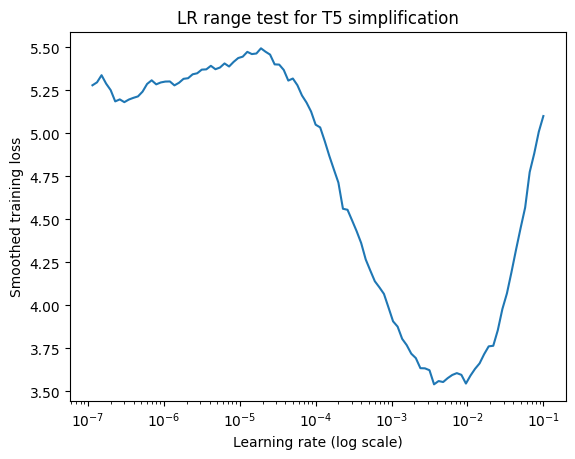

Minimum-loss LR ~ 3.63e-03
Suggested LR (10x smaller) ~ 3.63e-04


In [13]:
# Temporarily comment out the actual training while you run the LR finder:
# trainer.train()
import matplotlib.pyplot as plt
lrs, losses = lr_range_test(
    trainer,
    start_lr=1e-7,
    end_lr=1e-1,
    num_iter=100,
)

plt.figure()
plt.plot(lrs, losses)
plt.xscale("log")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Smoothed training loss")
plt.title("LR range test for T5 simplification")
plt.show()

best_lr_idx = np.argmin(losses)
best_lr = lrs[best_lr_idx]
print(f"Minimum-loss LR ~ {best_lr:.2e}")
print(f'Suggested LR (10x smaller) ~ {best_lr/10:.2e}')


In [9]:
trainer.train()

# Save final model + tokenizer
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Fk Grade Pred,Fre Pred,Jargon Pct Pred
1,2.104400,2.123625,0.173441,0.060413,0.139628,9.397184,48.344885,24.807185
2,2.285000,2.093179,0.174159,0.062973,0.143117,9.937202,44.371390,25.461047


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


('./t5-simplification-cochrane\\tokenizer_config.json',
 './t5-simplification-cochrane\\special_tokens_map.json',
 './t5-simplification-cochrane\\spiece.model',
 './t5-simplification-cochrane\\added_tokens.json',
 './t5-simplification-cochrane\\tokenizer.json')

In [3]:
# Load your clinical dataset (already preprocessed in Part 1)
# Make sure this path matches where you saved filtered_ds / work_ds
clinical_ds = load_from_disk("data/filtered_ds")
clinical_ds = clinical_ds.shuffle(seed=42).select(range(1000))


TECH_SUMMARY_COL = "brief_summary"

# Load the generic simplifier
base_model_dir = "./t5-simplification-cochrane"
tokenizer = AutoTokenizer.from_pretrained(base_model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(base_model_dir)
model.eval()
if torch.cuda.is_available():
    model.to("cuda")

In [4]:
def add_simplify_input(example):
    text = example[TECH_SUMMARY_COL]
    if text is None:
        text = ""
    example["simplify_input"] = f"Rephrase for better understanding from patient point of view: {text}"
    example["simplify_source_text"] = text
    return example

clinical_ds = clinical_ds.map(add_simplify_input)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
def add_input_metrics(example):
    src = example["simplify_source_text"]
    rm = readability_metrics(src)
    example["fk_in"] = rm["fk_grade"]
    example["gunning_fog_in"] = rm["gunning_fog"]
    example["smog_in"] = rm["smog_index"]
    example["flesch_reading_ease_in"] = rm["flesch_reading_ease"]
    example["jargon_in"] = jargon_ratio(src)
    return example

clinical_ds = clinical_ds.map(add_input_metrics)  # batched=False by default

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:

import torch


def generate_and_score(batch):
    texts = batch["simplify_input"]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt",
    )

    input_ids = inputs["input_ids"].to(model.device)
    attention_mask = inputs["attention_mask"].to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=128,
        )

    decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

    # Only OUT metrics here (IN metrics already precomputed)
    fk_out, fre_out, jar_out = [], [], []
    gf_out, smog_out = [], []

    for out in decoded:
        rm_out = readability_metrics(out)
        fk_out.append(rm_out["fk_grade"])
        gf_out.append(rm_out["gunning_fog"])
        smog_out.append(rm_out["smog_index"])
        fre_out.append(rm_out["flesch_reading_ease"])
        jar_out.append(jargon_ratio(out))

    batch["pseudo_simple"] = decoded

    batch["fk_out"] = fk_out
    batch["gunning_fog_out"] = gf_out
    batch["smog_out"] = smog_out
    batch["flesch_reading_ease_out"] = fre_out
    batch["jargon_out"] = jar_out

    return batch


clinical_with_pseudo = clinical_ds.map(
    generate_and_score,
    batched=True,
    batch_size=128,
)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [12]:
i = 888
print(clinical_with_pseudo[i]["simplify_input"])
print("AA")
print(clinical_with_pseudo[i]["pseudo_simple"])
print(clinical_with_pseudo[i]["fk_in"])
print(clinical_with_pseudo[i]["fk_out"])

Rephrase for better understanding from patient point of view: The goal of this randomized controlled trial is to determine if a counseling intervention, Project Safe Guard-Trauma (PSG-T), increases secure firearm storage practices in adults who screen positive for posttraumatic stress disorder (PTSD). The main questions this study aims to answer are:

* Does PSG-T lead to more secure firearm storage practices?
* Does PSG-T increase knowledge about the link between firearm storage practices and suicide risk?
* Does PSG-T increase intentions to store firearms securely?

Researchers will compare PSG-T to a control, Project Safe Guard (PSG), which is a counseling intervention that does not focus on the potential influence of PTSD symptoms on firearm storage practices. This will help to determine if PSG-T works better than PSG to increase secure firearm storage in adults with elevated PTSD symptoms.

Participants will:

* Complete a baseline survey
* Receive the counseling intervention
* Co

In [8]:
def is_zero_fre(example):
    return example["flesch_reading_ease_out"] == 0

subset = clinical_with_pseudo.filter(is_zero_fre)
print(len(subset))

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

0


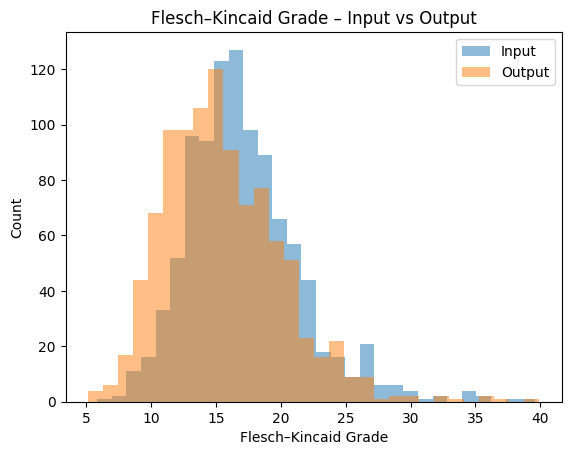

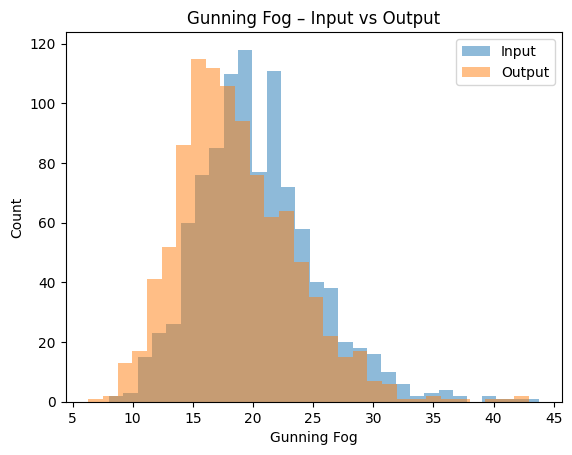

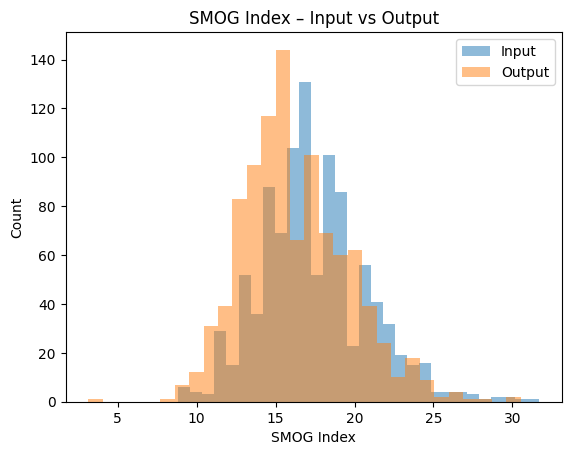

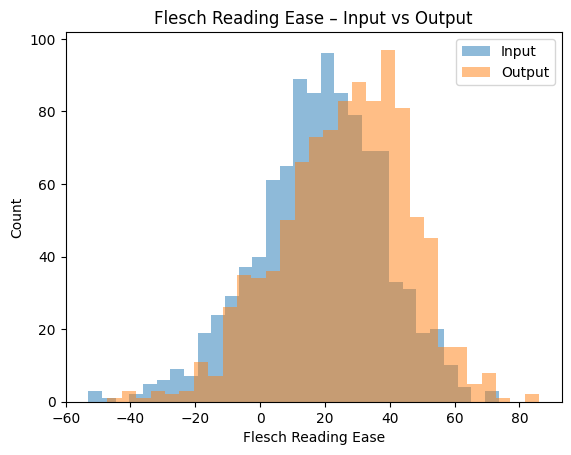

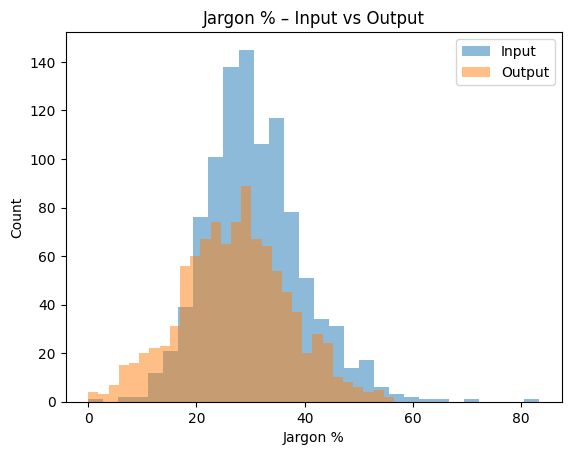

In [9]:
import matplotlib.pyplot as plt

df = clinical_with_pseudo.to_pandas()

metrics = [
    ("fk", "Flesch–Kincaid Grade"),
    ("gunning_fog", "Gunning Fog"),
    ("smog", "SMOG Index"),
    ("flesch_reading_ease", "Flesch Reading Ease"),
    ("jargon", "Jargon %"),
]

for key, title in metrics:
    in_col = f"{key}_in"
    out_col = f"{key}_out"

    plt.figure()
    plt.hist(df[in_col].dropna(), bins=30, alpha=0.5, label="Input")
    plt.hist(df[out_col].dropna(), bins=30, alpha=0.5, label="Output")
    plt.title(f"{title} – Input vs Output")
    plt.xlabel(title)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [11]:
# import numpy as np
#
# fk_arr = np.array(clinical_with_pseudo["fk_out"], dtype=float)
# fre_arr = np.array(clinical_with_pseudo["flesch_reading_ease_out"], dtype=float)
#
# # keep only finite values for quantiles
# fk_finite  = fk_arr[np.isfinite(fk_arr)]
# fre_finite = fre_arr[np.isfinite(fre_arr)]
#
# fk_q80  = np.quantile(fk_finite,  0.8)
# fre_q80 = np.quantile(fre_finite, 0.8)
#
# def top20_three_metrics(ex):
#     fk = ex["fk_out"]
#     fre = ex["flesch_reading_ease_out"]
#
#     # drop NaNs / inf
#     if not (np.isfinite(fk) and np.isfinite(fre)):
#         return False
#
#     return (
#         fk  >= fk_q80  and
#         fre >= fre_q80
#     )
#
# pseudo_train_ds = clinical_with_pseudo.filter(top20_three_metrics)
# print(len(pseudo_train_ds))


Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

17


In [12]:
# print(pseudo_train_ds[0]["brief_summary"])
# print("AA")
# print(pseudo_train_ds[0]["pseudo_simple"])

The aim of the study is to assess the effect of Methylphenidate on cognitive performance and decision-making ability of ADHD adults, and to compare this effect to the effect on healthy control adults.
AA
Die es ist es, es ist einfacher zu patient-friendly english: Die Ziel der Stud ist es, zu evaluieren, es ist, die Wirkung von Methylphenidate auf die cognitive performance und die Entscheidungsfähigkeit von ADHD adults, und zu vergleichen, es ist, es ist, es ist, es ist, es es es e e e e e e e e


In [50]:
# from datasets import DatasetDict
#
# # If you want, split into train/val
# pseudo_train_val = pseudo_train_ds.train_test_split(test_size=0.1, seed=42)
# train_ds = pseudo_train_val["train"]
# val_ds = pseudo_train_val["test"]
#
# max_input_length = 256
# max_target_length = 256  # summaries may be a bit longer
#
# def preprocess_pseudo(batch):
#     inputs = [
#         f"simplify to patient-friendly english: {txt}"
#         for txt in batch["simplify_source_text"]
#     ]
#     model_inputs = tokenizer(
#         inputs,
#         max_length=max_input_length,
#         truncation=True,
#         padding="max_length",
#     )
#
#     with tokenizer.as_target_tokenizer():
#         labels = tokenizer(
#             batch["pseudo_simple"],
#             max_length=max_target_length,
#             truncation=True,
#             padding="max_length",
#         )["input_ids"]
#
#     model_inputs["labels"] = labels
#     return model_inputs
#
# tokenized_train = train_ds.map(
#     preprocess_pseudo,
#     batched=True,
#     remove_columns=train_ds.column_names,
# )
#
# tokenized_val = val_ds.map(
#     preprocess_pseudo,
#     batched=True,
#     remove_columns=val_ds.column_names,
# )


Map:   0%|          | 0/4168 [00:00<?, ? examples/s]

C:\Users\Flaviu\miniconda3\envs\nlp\Lib\site-packages\transformers\tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/464 [00:00<?, ? examples/s]

In [51]:
# output_dir = "./t5-simplification-clinical-pseudo"
#
# batch_size = 8
# num_train_epochs = 2  # often 1–3 is enough for adaptation
#
# training_args = Seq2SeqTrainingArguments(
#     output_dir=output_dir,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5,  # a bit lower for continued fine-tuning
#     per_device_train_batch_size=batch_size,
#     per_device_eval_batch_size=batch_size,
#     weight_decay=0.01,
#     save_total_limit=2,
#     num_train_epochs=num_train_epochs,
#     predict_with_generate=True,
#     logging_steps=100,
#     report_to=["none"],
#     load_best_model_at_end=True,
#     metric_for_best_model="fk_grade_pred",  # or "rougeL" or custom
#     greater_is_better=False,  # lower FK grade is better
# )
#
# data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
#
# trainer = Seq2SeqTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_train,
#     eval_dataset=tokenized_val,
#     tokenizer=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )
#
# trainer.train()
#
# trainer.save_model(output_dir)
# tokenizer.save_pretrained(output_dir)


C:\Users\Flaviu\AppData\Local\Temp\ipykernel_22536\3732271647.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Fk Grade Pred,Fre Pred,Jargon Pct Pred
1,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


('./t5-simplification-clinical-pseudo\\tokenizer_config.json',
 './t5-simplification-clinical-pseudo\\special_tokens_map.json',
 './t5-simplification-clinical-pseudo\\spiece.model',
 './t5-simplification-clinical-pseudo\\added_tokens.json',
 './t5-simplification-clinical-pseudo\\tokenizer.json')